[*********************100%***********************]  2 of 2 completed


Dados carregados com sucesso!
Período: 2016-06-01 até 2026-05-29
Total de dias: 2483
Retorno acumulado: 254.58%
Volatilidade anual: 22.79%
[{'data': '01/06/2016', 'valor': '0.052531'}, {'data': '02/06/2016', 'valor': '0.052531'}, {'data': '03/06/2016', 'valor': '0.052531'}, {'data': '06/06/2016', 'valor': '0.052531'}, {'data': '07/06/2016', 'valor': '0.052531'}]
         data     valor
0  01/06/2016  0.052531
1  02/06/2016  0.052531
2  03/06/2016  0.052531
3  06/06/2016  0.052531
4  07/06/2016  0.052531
Taxa Selic anualizada média no período: 9.40%
Índice de Sharpe: 0.48


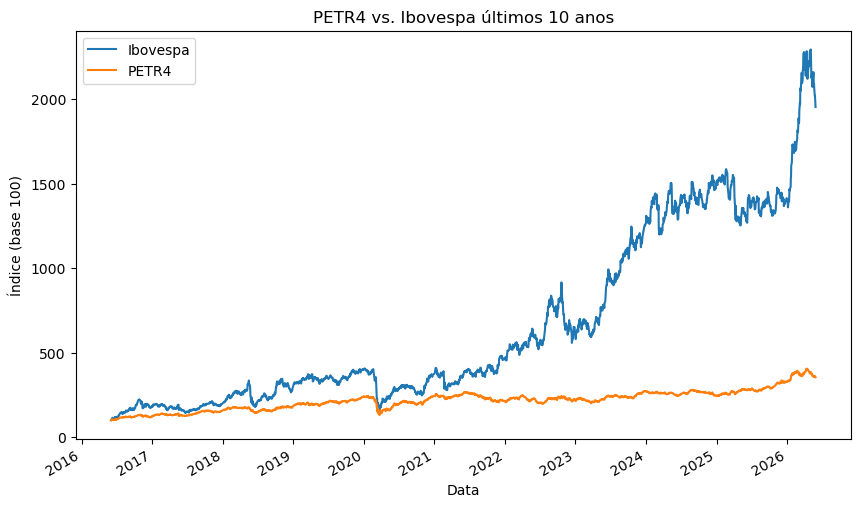

In [ ]:
# ================
# Asset Analysis - Historical Risk and Return
# PETR4 (Petrobrás) vs Ibovespa (IBOV)
# ================

import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import requests

# Período de análise: ~10 anos e meio de dados diários,
# para capturar diferentes ciclos econômicos (crise de 2016,
# pandemia de 2020 e o ciclo de alta recente)

ticker = "PETR4.SA"
benchmark = "^BVSP"

# Download dos preços de fechamento da PETR4 e do Ibovespa no mesmo período,
# para permitir comparação direta entre o ativo e o mercado
dados = yf.download([ticker, benchmark],
                    start="2016-06-01",
                    end="2026-06-01")["Close"]

dados.columns = ["Ibovespa", "PETR4"]
dados = dados.dropna()  # remove dias sem cotação em algum dos dois ativos

print("Dados carregados com sucesso!")
print(f"Período: {dados.index[0].date()} até {dados.index[-1].date()}")
print(f"Total de dias: {len(dados)}")

# ------------------------------------------------
# Retorno e volatilidade da PETR4
# ------------------------------------------------

# Retorno acumulado: variação percentual entre o primeiro e o último preço do período
retorno_acumulado = (dados["PETR4"].iloc[-1] - dados["PETR4"].iloc[0]) / dados["PETR4"].iloc[0]
print(f"Retorno acumulado: {retorno_acumulado:.2%}")

# Retornos diários (variação percentual dia a dia), usados para medir o risco do ativo
retorno_ativo = dados["PETR4"].pct_change().dropna()
volatilidade_diaria = retorno_ativo.std()

# Volatilidade anualizada: desvio padrão diário escalado por raiz de 252
# (número aproximado de dias de pregão por ano)
volatilidade_anual = volatilidade_diaria * np.sqrt(252)
print(f"Volatilidade anual: {volatilidade_anual:.2%}")

# Retorno anualizado: converte o retorno acumulado do período inteiro
# em uma taxa equivalente "por ano", para poder comparar com a Selic anual
retorno_anualizado = ((1 + retorno_acumulado) ** (1 / (len(dados) / 365))) - 1

# ------------------------------------------------
# Selic (taxa livre de risco) e Índice de Sharpe
# ------------------------------------------------

# Busca a série histórica da Selic diária via API do Banco Central (SGS, série 11),
# usada como referência de retorno livre de risco no cálculo do Sharpe
url = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.11/dados?formato=json&dataInicial=01/06/2016&dataFinal=01/06/2026"
resposta = requests.get(url)
selic_json = resposta.json()
print(selic_json[:5])

selic_df = pd.DataFrame(selic_json)
selic_df["valor"] = selic_df["valor"].astype(float)  # a API retorna como texto
print(selic_df.head())

# Anualiza a Selic diária média do período por composição (juros compostos),
# para ficar na mesma unidade de tempo do retorno anualizado da PETR4
selic_diaria_media = selic_df["valor"].mean() / 100
selic_anual = (selic_diaria_media + 1) ** 252 - 1
print(f"Taxa Selic anualizada média no período: {selic_anual:.2%}")

# Índice de Sharpe: mede o retorno em excesso (acima da taxa livre de risco)
# obtido por unidade de risco (volatilidade) assumida
indice_sharpe = (retorno_anualizado - selic_anual) / volatilidade_anual
print(f"Índice de Sharpe: {indice_sharpe:.2f}")

# ------------------------------------------------
# Visualização: PETR4 vs Ibovespa
# ------------------------------------------------

# Normaliza as duas séries para base 100, já que têm escalas de preço muito diferentes
# (assim é possível comparar a performance relativa dos dois no mesmo gráfico)
dados_normalizados = dados / dados.iloc[0] * 100

dados_normalizados.plot(figsize=(10, 6), title="PETR4 vs. Ibovespa últimos 10 anos")
plt.xlabel("Data")
plt.ylabel("Índice (base 100)")
plt.show()
